In [2]:
import numpy as np
import qutip as qt
import pandas as pd
import matplotlib.pyplot as plt


# Simulation on syntetic "lab" environment dataset

Sensing window T sets which frequency each sequence is tuned to (peak near N/(2T)). For a 50 Hz target, T = 20 ms with CPMG-2 gives a peak almost exactly at 50 Hz — so that's our natural operating point.

In [3]:
from filter import filter_fun


In [4]:
T = 0.02 
for i in [0,1,2,4,8]:
    f = np.linspace(1, 300, 3000)
    F = filter_fun(2*np.pi*f, T, i)
    print(i, "peak at", f[np.argmax(F)], "Hz")

0 peak at 1.0 Hz
1 peak at 37.09136378792931 Hz
2 peak at 57.430143381127046 Hz
4 peak at 104.08969656552185 Hz
8 peak at 202.09469823274426 Hz


In [5]:
# CPMG-2 almost at 50Hz so finetune that: peak*T = 1.1486 --> f~= 49.970985 Hz
T = 1.14794/50
f = np.linspace(1, 150, 5000)
F = filter_fun(2*np.pi*f, T, 2, n_points=3000)
print('T =', T*1000, "ms", "peak at", f[np.argmax(F)], "Hz")

T = 22.958799999999997 ms peak at 50.001000200040004 Hz


## Generating the dataset


We simulate the raw magnetic field time series a sensor sitting in a
real lab would see -- our 50 Hz cable signal PLUS a handful of
realistic interference sources, so detection is a genuine problem and
not a toy. Sampled finely enough to resolve everything up to a few
hundred Hz.
 
Noise sources included (all standard real-lab culprits):
  - 50 Hz mains cable (the TARGET signal we want to detect)
  - harmonics of the cable itself (100, 150 Hz) -- real AC current
    is rarely a pure sinusoid
  - a nearby motor/fan at 23 Hz (mechanical vibration -> magnetic
    coupling via a ferromagnetic part, very common lab interferer)
  - a second piece of equipment at 62 Hz (switching supply, unrelated
    device on a different phase)
  - slow correlated drift (Lorentzian PSD, e.g. thermal / building
    HVAC-driven baseline wander)
  - white sensor/readout noise floor

In [6]:
from env_dataset import lab_dataset

def compute_spec(signal, sample_rate):
    n = len(signal)
    freq = np.fft.rfftfreq(n, d=1 / sample_rate)
    spectrum = np.abs(np.fft.rfft(signal)) /n
    return freq, spectrum

df = lab_dataset()
sample_rate = 1 / (df['time_s'][1] - df['time_s'][0])

Saved lab_dataset_overview.png


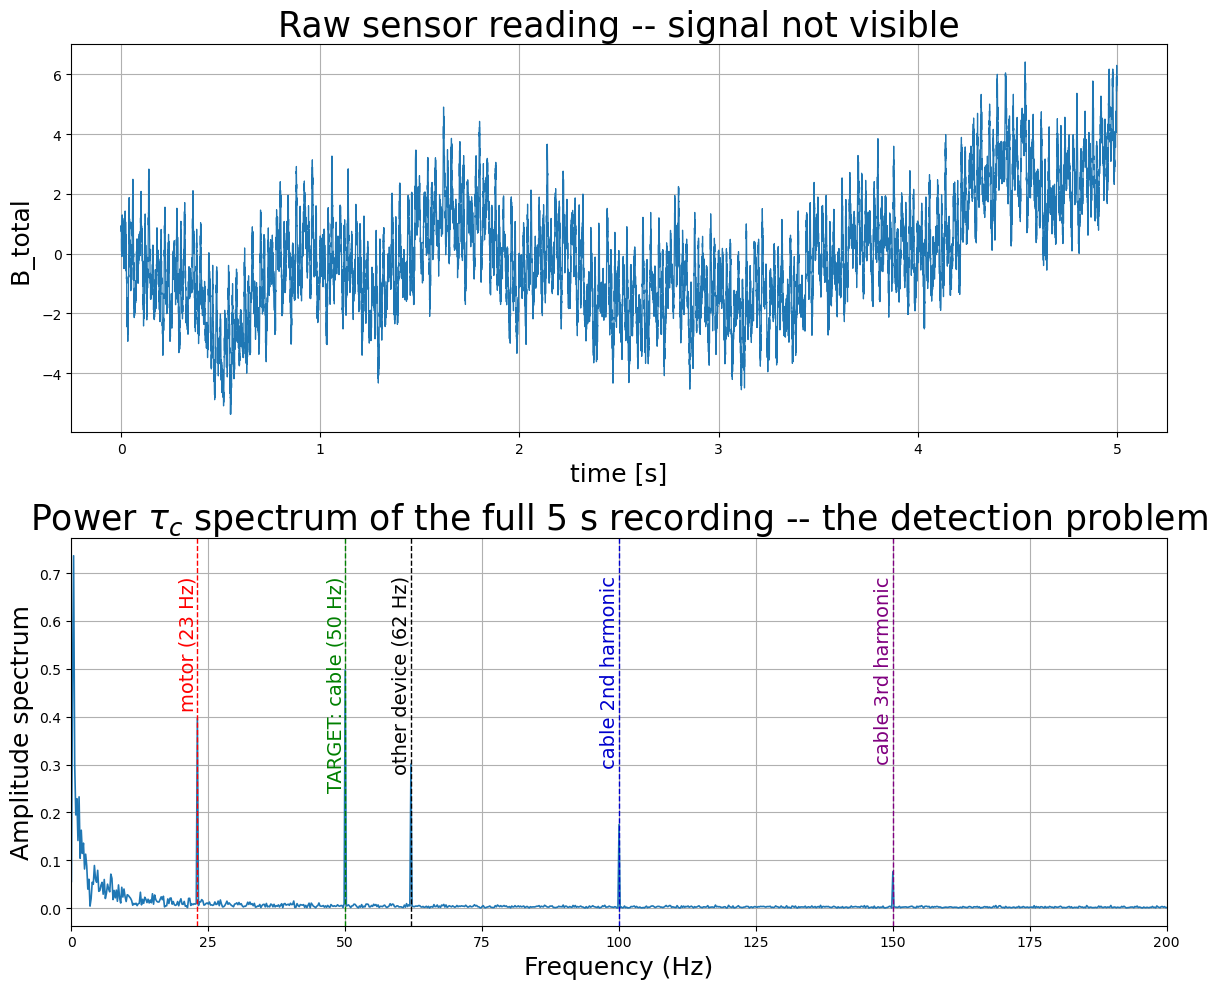

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
#mask = df['time_s'] < 0.2

ax[0].plot(df["time_s"], df['B_total'], lw=0.9)
ax[0].set_xlabel("time [s]",  fontsize=18)
ax[0].set_ylabel("B_total ",  fontsize=18)
ax[0].set_title("Raw sensor reading -- signal not visible",  fontsize=25)
ax[0].grid(True)

freq, spec = compute_spec(df["B_total"].values, sample_rate)
ax[1].plot(freq, spec, lw=1.2)

for f0, label, color in [
        (23, "motor (23 Hz)", "red"),
        (50, "TARGET: cable (50 Hz)", "green"),
        (62, "other device (62 Hz)", "black"),
        (100, "cable 2nd harmonic", "mediumblue"),
        (150, "cable 3rd harmonic", "purple"),
    ]:
        ax[1].axvline(f0, color=color, ls="--", lw=1)
        ax[1].text(f0, ax[1].get_ylim()[1] * 0.9, label, rotation=90,
                     fontsize=14, ha="right", va="top", color=color)
ax[1].set_xlim(0, 200)
ax[1].set_xlabel("Frequency (Hz)", fontsize=18)
ax[1].set_ylabel("Amplitude spectrum",  fontsize=18)
ax[1].set_title(r"Power spectrum of the full 5 s recording -- the detection problem",  fontsize=25)

ax[1].grid(True)

fig.tight_layout()
#fig.savefig("lab_dataset_overview.png", dpi=150)
print("Saved lab_dataset_overview.png")